# Strategy: Multi-Index Trend Strategy with EMAs

## 1. Strategy overview
This code executes a trend-following intraday breakout trading strategy across a portfolio of global index CFDs (such as US30, US500, GER40, etc.) on a 5-minute timeframe, complete with a backtesting framework and portfolio evaluation.

## 2. Theoretical rules
### 1. Session:
- Trading window: New trades are only opened between 10:00 AM and 11:00 PM (time(10, 0) to time(23, 0)).
- Intraday cycle: The backtest runs day-by-day (run_period_backtest), evaluating each trading day independently and skipping weekends.

### 2. Trend identification and entry rules
The strategy trades strictly in the direction of the macro trend using a combination of Exponential Moving Averages (EMAs) and EMA Crossovers:
- Uptrend Condition: Current Close $>$ EMA(100) 
    - Buy Trigger: Previous Close $<$ EMA(20) AND Current Close $>$ EMA(20) (bullish crossover above EMA 20).
- Downtrend Condition: Current Close $<$ EMA(100)
    - Sell Trigger: Previous Close $>$ EMA(20) AND Current Close $<$ EMA(20) (bearish crossover below EMA 20).

### 3. Fractal Stop Loss & Take Profit
When an entry condition triggers, the algorithm identifies dynamic support and resistance levels using Fractals:
- Fractal Definition: A candle is marked as a Fractal Low if its Low is the lowest in a window of $50$ candles before and after (FRACTAL_DISTANCE = 50).
- Long Position (Buy):
    - Stop Loss (SL): Placed at the most recent Fractal Low minus a small buffer (0.8 points).
    - Take Profit (TP): Set at a fixed 3:1 Risk-to-Reward Ratio (RR = 3), i.e., $\text{Entry} + 3 \times (\text{Entry} - \text{SL})$.

- Short Position (Sell):
    - Stop Loss (SL): Placed at the most recent Fractal High plus a buffer (0.8 points).
    - Take Profit (TP): Set at $\text{Entry} - 3 \times (\text{SL} - \text{Entry})$.
    
### 4. Risk and size
- Risk Limit: Calculates exact lot sizes so each trade risks a fixed $0.05\%$ of account balance (RISK_PERCENT = 0.0005 of a $\$10,000$ account $\rightarrow \$5$ risk per trade).
- Broker Calibration: Dynamically queries MetaTrader 5 (mt5.symbol_info) for tick size and tick value to compute proper lot sizes bounded by minimum and maximum broker volume constraints.

### 5. Daily limits and exits
- Exit conditions: Monitored candle-by-candle for SL or TP hits. Any trade still open at the end of the day is force-closed at market close.
- Daily Profit/Loss Capping:Evaluates daily performance with optional circuit breakers: stopping further trades for the day if a daily profit target ($+\$30$) or daily stop loss ($-\$20$) is hit. I chose +$30 (+6R) and -$20 (-4R) because they equal winning 2 net trades or losing 4 consecutive trades in a single day, protecting the capital during volatile markets while be in profits when the trend is strong.
- Portfolio metrics and plotting: Outputs Profit Factor, Annualized Sharpe Ratio, Win Days percentage per symbol and across the aggregated portfolio, along with a cumulative PnL chart.

Processing backtest for symbol: AUS200.cash
Processing backtest for symbol: US30.cash
Processing backtest for symbol: EU50.cash
Processing backtest for symbol: GER40.cash
Processing backtest for symbol: HK50.cash
Processing backtest for symbol: JP225.cash
Processing backtest for symbol: US100.cash
Processing backtest for symbol: US500.cash
Processing backtest for symbol: UK100.cash
Processing backtest for symbol: US2000.cash
Processing backtest for symbol: SPN35.cash
                    INDIVIDUAL SYMBOL SUMMARIES: 

 SYMBOL: AUS200.cash
   ├─ PnL:   $569.03 (919 trades)
   ├─ Capped PnL (TP/SL): $408.04 (823 trades)
   ├─ Trades saved:         96
   ├─ Profit Factor:            1.60
   ├─ Sharpe Ratio (annualized):3.99
   └─ Win days:           60 of 99 (60.6%)

 SYMBOL: US30.cash
   ├─ PnL:   $831.23 (1003 trades)
   ├─ Capped PnL (TP/SL): $477.28 (699 trades)
   ├─ Trades saved:         304
   ├─ Profit Factor:            1.46
   ├─ Sharpe Ratio (annualized):3.80
   └─ Win days:    

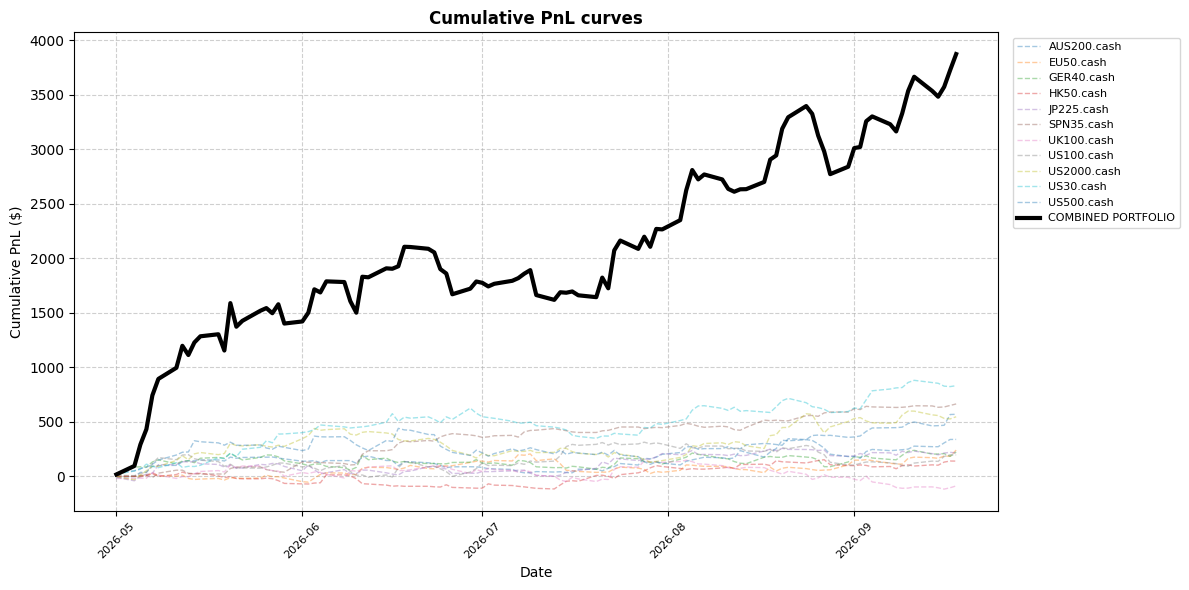

In [4]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timedelta, time
from dataclasses import dataclass
import logging

logging.basicConfig(level=logging.INFO)

SYMBOLS = [
    "AUS200.cash",
    "US30.cash",
    "EU50.cash",
    "GER40.cash",
    "HK50.cash",
    "JP225.cash",
    "US100.cash",
    "US500.cash",
    "UK100.cash",
    "US2000.cash",
    "SPN35.cash",
]
TIMEFRAME = mt5.TIMEFRAME_M5
RISK_PERCENT = 0.0005
ACCOUNT_SIZE = 10000
BUFFER = 0.8
RR = 3
FRACTAL_DISTANCE = 50


@dataclass
class Trade:
    symbol: str
    entry_time: pd.Timestamp
    side: str
    entry: float
    sl: float
    tp: float
    volume: float
    exit_time: pd.Timestamp = None
    exit_price: float = None
    pnl: float = 0.0


def detect_fractals(df: pd.DataFrame, d: int = 5) -> pd.DataFrame:
    df['fractal_high'] = False
    df['fractal_low'] = False
    for i in range(d, len(df) - d):
        if df['low'].iloc[i] == min(df['low'].iloc[i - d : i + d + 1]):
            df.at[i, 'fractal_low'] = True
        if df['high'].iloc[i] == max(df['high'].iloc[i - d : i + d + 1]):
            df.at[i, 'fractal_high'] = True
    return df


def calculate_lot(symbol: str, entry: float, sl: float) -> float:
    info = mt5.symbol_info(symbol)
    if not info:
        return 0.1
    tick_value = info.trade_tick_value
    tick_size = info.trade_tick_size
    risk_points = abs(entry - sl)
    if risk_points == 0:
        return 0.1

    lot_risk_value = (risk_points / tick_size) * tick_value
    if lot_risk_value > 0:
        lot = (ACCOUNT_SIZE * RISK_PERCENT) / lot_risk_value
    else:
        lot = 0.0

    # Rrestrict to broker limits
    lot = max(lot, info.volume_min)
    lot = min(lot, info.volume_max)
    return round(lot, 2)


def backtest(start: datetime, stop: datetime, symbol: str) -> list[Trade]:
    pre_start = start - timedelta(minutes=5000)
    rates = mt5.copy_rates_range(symbol, TIMEFRAME, pre_start, stop)

    if rates is None or len(rates) == 0:
        return []

    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df['ema20'] = df['close'].ewm(span=20, adjust=False).mean()
    df['ema100'] = df['close'].ewm(span=100, adjust=False).mean()
    df = detect_fractals(df, FRACTAL_DISTANCE)

    active_trades: list[Trade] = []
    closed_trades: list[Trade] = []

    for i in range(100, len(df)):
        row = df.iloc[i]
        prev = df.iloc[i - 1]

        # Exits:
        for trade in active_trades[:]:
            execute_close = False
            exit_price = 0.0

            if trade.side == 'buy':
                if row.low <= trade.sl:
                    exit_price = min(trade.sl, row.open)
                    execute_close = True
                elif row.high >= trade.tp:
                    exit_price = max(trade.tp, row.open)
                    execute_close = True

            else:  # side == 'sell'
                if row.high >= trade.sl:
                    exit_price = max(trade.sl, row.open)
                    execute_close = True
                elif row.low <= trade.tp:
                    exit_price = min(trade.tp, row.open)
                    execute_close = True

            if execute_close:
                trade.exit_price = exit_price
                trade.exit_time = row.time
                move = (
                    (trade.exit_price - trade.entry)
                    if trade.side == 'buy'
                    else (trade.entry - trade.exit_price)
                )
                info = mt5.symbol_info(symbol)
                trade.pnl = (
                    (move / info.trade_tick_size)
                    * info.trade_tick_value
                    * trade.volume
                )
                closed_trades.append(trade)
                active_trades.remove(trade)

        if row.time < start:
            continue

        # Entries:
        current_time = row.time.time()
        if not (time(10, 0) <= current_time <= time(23, 0)):
            continue

        is_uptrend = row.close > row.ema100
        is_downtrend = row.close < row.ema100
        cross_up = prev.close < prev.ema20 and row.close > row.ema20
        cross_down = prev.close > prev.ema20 and row.close < row.ema20

        # Buy
        if is_uptrend and cross_up:
            lows = df[(df.fractal_low) & (df.index < i)]
            if not lows.empty:
                sl = lows.iloc[-1].low - BUFFER
                entry = row.close
                if sl < entry:
                    lot = calculate_lot(symbol, entry, sl)
                    active_trades.append(
                        Trade(
                            symbol,
                            row.time,
                            'buy',
                            entry,
                            sl,
                            entry + RR * (entry - sl),
                            lot,
                        )
                    )

        # Sell
        elif is_downtrend and cross_down:
            highs = df[(df.fractal_high) & (df.index < i)]
            if not highs.empty:
                sl = highs.iloc[-1].high + BUFFER
                entry = row.close
                if sl > entry:
                    lot = calculate_lot(symbol, entry, sl)
                    active_trades.append(
                        Trade(
                            symbol,
                            row.time,
                            'sell',
                            entry,
                            sl,
                            entry - RR * (sl - entry),
                            lot,
                        )
                    )

    # Forced exit for open trades
    for t in active_trades:
        t.exit_price = df.iloc[-1].close
        t.exit_time = df.iloc[-1].time
        move = (
            (t.exit_price - t.entry)
            if t.side == 'buy'
            else (t.entry - t.exit_price)
        )
        info = mt5.symbol_info(symbol)
        t.pnl = (
            (move / info.trade_tick_size) * info.trade_tick_value * t.volume
        )
        closed_trades.append(t)

    return closed_trades


def run_period_backtest(start_date: datetime, days: int, symbol: str) -> list[Trade]:
    all_trades: list[Trade] = []

    for d in range(days):
        current_day = start_date + timedelta(days=d)

        if current_day.weekday() >= 5:
            continue

        day_start = datetime.combine(current_day, time(10, 0))
        day_end = datetime.combine(current_day, time(23, 0))

        day_trades = backtest(day_start, day_end, symbol)
        all_trades.extend(day_trades)

    return all_trades


def perform_portfolio_analysis(all_symbol_trades: dict[str, list[Trade]], profit_limit: float = 30.0, loss_limit: float = -20.0):
    daily_records = []
    trade_records = []

    for symbol, trades in all_symbol_trades.items():
        if not trades:
            continue
        df_t = pd.DataFrame([t.__dict__ for t in trades])
        df_t['entry_time'] = pd.to_datetime(df_t['entry_time'])
        df_t['date'] = df_t['entry_time'].dt.date
        trade_records.append(df_t)

        for date, group in df_t.groupby('date'):
            group = group.sort_values('entry_time')
            cum_pnl = group['pnl'].cumsum()

            capped_pnl = cum_pnl.iloc[-1]
            capped_trades = len(group)
            cut_reason = "Normal"

            for i, pnl in enumerate(cum_pnl):
                if pnl >= profit_limit:
                    capped_pnl = pnl
                    capped_trades = i + 1
                    cut_reason = "Daily TP"
                    break
                elif pnl <= loss_limit:
                    capped_pnl = pnl
                    capped_trades = i + 1
                    cut_reason = "Daily SL"
                    break

            daily_records.append(
                {
                    'symbol': symbol,
                    'date': date,
                    'num_trades': len(group),
                    'capped_trades': capped_trades,
                    'net_real': cum_pnl.iloc[-1],
                    'max_peak': cum_pnl.max(),
                    'min_peak': cum_pnl.min(),
                    'net_lim': capped_pnl,
                    'cut_reason': cut_reason,
                }
            )

    if not daily_records:
        print("No trade data available for portfolio aggregation.")
        return

    df_daily = pd.DataFrame(daily_records)
    df_all_trades = pd.concat(trade_records, ignore_index=True)

    # Pivot table PnL diari per symbol
    daily_pnl_pivot = df_daily.pivot(
        index='date', columns='symbol', values='net_real'
    ).fillna(0)

    daily_pnl_pivot['COMBINED_PORTFOLIO'] = daily_pnl_pivot.sum(axis=1)

    #  INDIVIDUAL SYMBOL SUMMARIES
    print("                    INDIVIDUAL SYMBOL SUMMARIES: ")

    for symbol in all_symbol_trades.keys():
        symbol_daily = df_daily[df_daily['symbol'] == symbol]
        symbol_trades = df_all_trades[df_all_trades['symbol'] == symbol]

        if symbol_daily.empty:
            continue

        net_real = symbol_daily['net_real'].sum()
        net_lim = symbol_daily['net_lim'].sum()
        trades_real = symbol_daily['num_trades'].sum()
        trades_lim = symbol_daily['capped_trades'].sum()

        gross_profit = symbol_trades[symbol_trades['pnl'] > 0]['pnl'].sum()
        gross_loss = abs(symbol_trades[symbol_trades['pnl'] < 0]['pnl'].sum())
        pf = gross_profit / gross_loss if gross_loss != 0 else 0.0

        daily_pnl = symbol_daily['net_real']
        mean_pnl = daily_pnl.mean()
        std_pnl = daily_pnl.std()

        if std_pnl > 0:
            sharpe_daily = mean_pnl / std_pnl
            sharpe_annual = sharpe_daily * np.sqrt(252)
        else:
            sharpe_daily = 0.0
            sharpe_annual = 0.0

        win_days = (daily_pnl > 0).sum()
        total_days = len(daily_pnl)

        print(f"\n SYMBOL: {symbol}")
        print(f"   ├─ PnL:   ${net_real:,.2f} ({int(trades_real)} trades)")
        print(f"   ├─ Capped PnL (TP/SL): ${net_lim:,.2f} ({int(trades_lim)} trades)")
        print(f"   ├─ Trades saved:         {int(trades_real - trades_lim)}")
        print(f"   ├─ Profit Factor:            {pf:.2f}")
        print(f"   ├─ Sharpe Ratio (annualized):{sharpe_annual:.2f}")
        print(f"   └─ Win days:           {win_days} of {total_days} ({(win_days/total_days)*100:.1f}%)")

    # COMBINED_PORTFOLIO SUMMARY 
    total_real = df_daily['net_real'].sum()
    total_lim = df_daily['net_lim'].sum()
    total_trades_real = df_daily['num_trades'].sum()
    total_trades_lim = df_daily['capped_trades'].sum()

    gross_profit_all = df_all_trades[df_all_trades['pnl'] > 0]['pnl'].sum()
    gross_loss_all = abs(df_all_trades[df_all_trades['pnl'] < 0]['pnl'].sum())
    portfolio_pf = gross_profit_all / gross_loss_all if gross_loss_all != 0 else 0.0

    portfolio_daily_pnl = daily_pnl_pivot['COMBINED_PORTFOLIO']
    port_mean = portfolio_daily_pnl.mean()
    port_std = portfolio_daily_pnl.std()

    if port_std > 0:
        port_sharpe_daily = port_mean / port_std
        port_sharpe_annual = port_sharpe_daily * np.sqrt(252)
    else:
        port_sharpe_daily = 0.0
        port_sharpe_annual = 0.0

    port_win_days = (portfolio_daily_pnl > 0).sum()
    port_total_days = len(portfolio_daily_pnl)

    print("                    COMBINED PORTFOLIO GLOBAL SUMMARY:")
    print(f"Total symbols:   {len(all_symbol_trades)}")
    print(f"PnL Portfolio:         ${total_real:,.2f} ({int(total_trades_real)} trades)")
    print(f"Capped PnL Portfolio:      ${total_lim:,.2f} ({int(total_trades_lim)} trades)")
    print(f"Trades saved: {int(total_trades_real - total_trades_lim)}")
    print(f"Profit Factor: {portfolio_pf:.2f}")
    print(f"Sharpe Ratio Portfolio (annualized):{port_sharpe_annual:.2f}")
    print(f"Win days:  {port_win_days} of {port_total_days} ({(port_win_days/port_total_days)*100:.1f}%)")

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    symbols_list = [
        s for s in daily_pnl_pivot.columns if s != "COMBINED_PORTFOLIO"
    ]

    for col in symbols_list:
        ax.plot(
            daily_pnl_pivot.index,
            daily_pnl_pivot[col].cumsum(),
            label=col,
            alpha=0.4,
            linestyle="--",
            linewidth=1,
        )

    ax.plot(
        daily_pnl_pivot.index,
        daily_pnl_pivot["COMBINED_PORTFOLIO"].cumsum(),
        label="COMBINED PORTFOLIO",
        color="black",
        linewidth=3,
    )

    ax.set_title(
        "Cumulative PnL curves",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_ylabel("Cumulative PnL ($)")
    ax.set_xlabel("Date")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=8)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    if mt5.initialize():
        start_date = datetime(2026, 5, 1)
        num_days = 150
        all_symbol_trades: dict[str, list[Trade]] = {}

        for symbol in SYMBOLS:
            print(f"Processing backtest for symbol: {symbol}")
            results = run_period_backtest(start_date, num_days, symbol)
            all_symbol_trades[symbol] = results

        perform_portfolio_analysis(all_symbol_trades)

        mt5.shutdown()

## 3. Performance and risk analysis

These results cover approximately four months of trading activity and should therefore be interpreted as a exploratory analysis rather than a definitive evaluation of strategy performance. The objective is not to identify a single "best" strategy or instrument, but to analyze how the trading framework behaves across different markets and risk-management configurations, and to identify variables that may allow further investigation.

### General performance

The unconstrained portfolio generated $3,872.73 across 10,111 trades, with a profit factor of 1.26, an annualized Sharpe ratio of 4.71, and positive results on 61 of 101 trading days (60.4%).

The capped TP/SL configuration reduced the number of trades to 8,175, saving 1,936 trades (19.1%), but also reduced portfolio PnL to $2,671.56. Therefore, the current TP/SL constraints reduce trading activity but do not improve aggregate profitability over the observed period.

However, their effect is not uniform across instruments. The capped configuration improves the results of EU50 and JP225, and reduces the magnitude of the loss on UK100, while decreasing PnL across most of the remaining markets. This suggests that the effect of the TP/SL mechanism is dependent of the market rather than generally beneficial.

Overall, 10 out of 11 instruments generated positive PnL, with UK100 being the only negative contributor. Several markets also exhibit relatively strong risk-adjusted performance, particularly SPN35 (Sharpe 4.92), AUS200 (3.99), and US30 (3.80).

### Portfolio performance

The results suggest that the positive portfolio performance is distributed across a relatively broad set of instruments rather than being driven exclusively by one market. SPN35, US30, US2000, AUS200, and US500 are among the best contributors to increase PnL, while other instruments also remain profitable.

SPN35 is particularly notable, combining $663.74 PnL, a 2.02 profit factor, and a 4.92 Sharpe ratio. AUS200 and US30 also show relatively strong risk-adjusted characteristics, with Sharpe ratios of 3.99** and 3.80, respectively.

In contrast, UK100 remains the only instrument with negative PnL, a profit factor below 1 (0.94), and a negative Sharpe ratio (-0.56). However, the longer sample also shows that its loss is considerably smaller relative to the positive contribution of the other markets.

The broader distribution of positive results provides more support for investigating the portfolio as a whole rather than focusing exclusively on individual instruments. Nevertheless, correlations between markets should be considered before changing allocations, since several instruments represent related equity markets.

### Capped configuration

The capped configuration removes approximately 19% of trades while reducing PnL by approximately 31% against the unconstrained portfolio.

This indicates that, under the current TP/SL parameters, some of the removed trades contributed positively to the overall strategy. The cap therefore appears to act primarily as a trade reduction mechanism, rather than improving profitability.

This fact suggests that future research could investigate specific TP/SL parameters instead of applying a single configuration for every market.

### Conclusion and further work

The four month sample provides stronger evidence of consistent positive performance across multiple instruments. The portfolio generated positive PnL across 10 of 11 markets and achieved a Sharpe ratio of 4.71, while maintaining positive results on approximately 60% of trading days.

Nevertheless, these results should still be treated as an intermediate research result rather than evidence of a persistent trading edge. Further validation across additional historical periods, market regimes, and out-of-sample data is required.

The next steps should therefore be to:
1. Test these relationships over a longer historical period and across different market regimes, focusing on the stability of the observed patterns rather than optimizing specifically for this sample.
2. Adapt the parameters (such as FRACTAL_DISTANCE, EMA, BUFFER, etc.) to each specific market. This could be done by machine learning algorithms that just minimize the weights.  
3. Instead of taking trades all day, add a volatility filter using for example the Average True Range (ATR). Trend-following breakout strategies fail when the market is inactive. Filter for active market conditions.
4. After all these improvements are taken into account, select the optimal quantity of each asset that maximizes the PnL and minimizes the risk. 